# Module 9: Clustering and Topic Modeling
This notebook supports Lecture 9 and covers K-Means, Hierarchical Clustering, and LDA.

## Objectives
- Understand clustering concepts
- Implement K-Means
- Explore hierarchical clustering
- Apply topic modeling using LDA

## What is Clustering?
Clustering is an unsupervised learning technique that groups similar data points together.

How K-Means Works:
- Initialization: Choose K initial centroids randomly from the dataset.
- Assignment Step: Assign each data point to the nearest centroid, forming K clusters.
- Update Step: Recalculate the centroids by taking the average of all points in each cluster.
- Repeat: Continue the assignment and update steps until the centroids no longer change significantly or until a set number of iterations is reached.

## K-Means Clustering Example

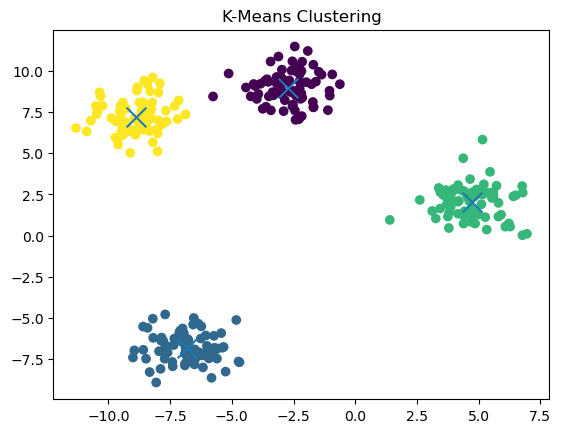

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generate synthetic data
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# Fit KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

centroids = kmeans.cluster_centers_
labels = kmeans.labels_

# Plot
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=200)
plt.title("K-Means Clustering")
plt.show()

## Choosing K (Elbow Method)

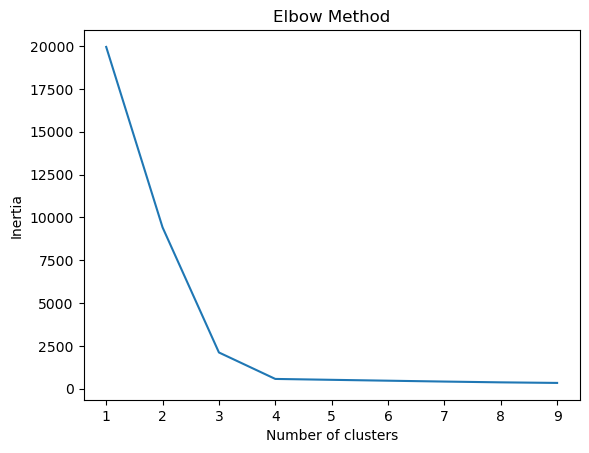

In [9]:
inertia = []
k_range = range(1, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(k_range, inertia)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## Hierarchical Clustering

There are two different approaches for hierarchical clustering and I will focus on what it is called agglomerative technique. The idea, in contrast with k-means is that we want to be able to depict the groups we are creating at multiple levels.

How agglomerative approach works?
- Treat each data point as a single cluster.
- Merge the closest pairs of clusters until only one cluster remains.
- The result can be represented as a dendrogram, which visually represents the merging process.

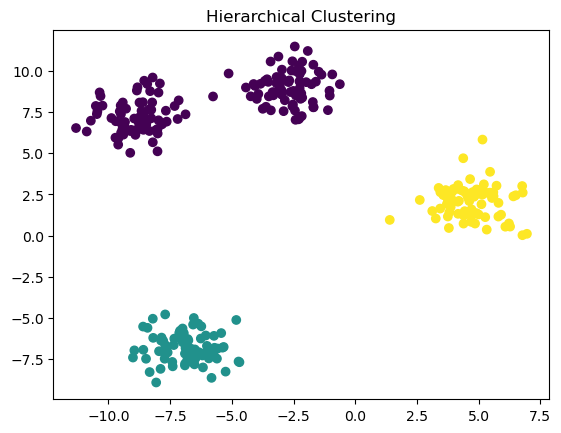

In [10]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("Hierarchical Clustering")
plt.show()

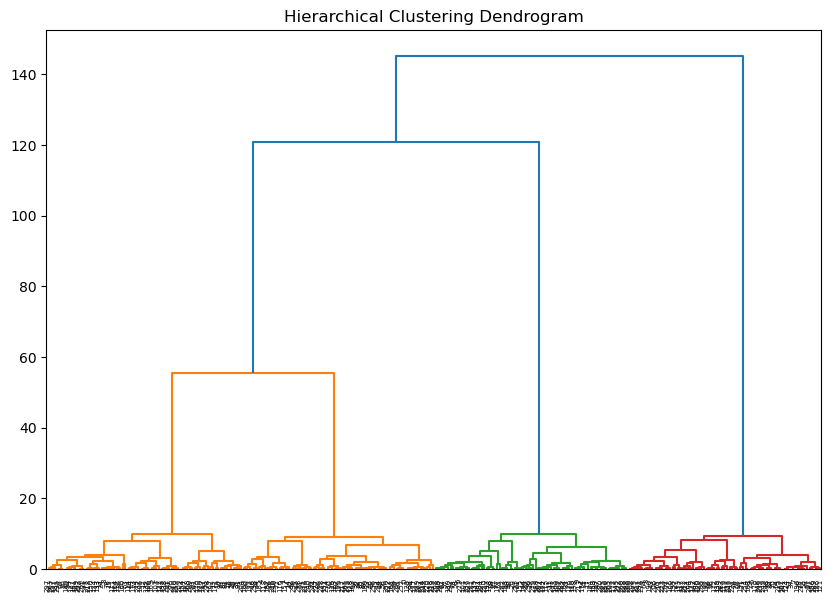

In [11]:
# Plotting the dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram
linked = linkage(X, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

## K-Means on Text Data

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
"Machine learning is a fascinating field",
"Python is great for data science",
"AI is transforming industries",
"Data science uses machine learning",
"Python programming is popular"
]

vectorizer = TfidfVectorizer(stop_words='english')
X_text = vectorizer.fit_transform(documents)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_text)

for i, label in enumerate(kmeans.labels_):
    print(f"Doc {i}: Cluster {label}")

Doc 0: Cluster 1
Doc 1: Cluster 0
Doc 2: Cluster 1
Doc 3: Cluster 1
Doc 4: Cluster 0


## Density-Based Clustering (DBSCAN)

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups points based on density, rather than distance to a centroid (like K-Means).

Key Concepts
- ε (epsilon): Radius around a point (neighborhood size)
- min_samples: Minimum number of points required to form a dense region
Types of points:
- Core point → Has enough neighbors (≥ min_samples)
- Border point → Close to a core point but not dense itself
- Noise point → Doesn’t belong to any cluster

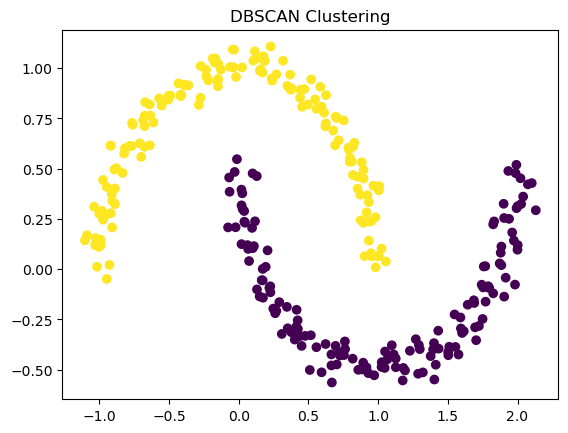

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# Generate non-linear data
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# Plot
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("DBSCAN Clustering")
plt.show()

## Topic Modeling with LDA

In [14]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim import corpora
from gensim.models import LdaModel
import string

nltk.download('punkt')
nltk.download('stopwords')

documents = [
"Machine learning is fascinating",
"Python is used in data science",
"AI and machine learning are important",
"Deep learning is a subset of ML"
]

def preprocess(text):
    tokens = word_tokenize(text.lower())
    stop_words = set(stopwords.words('english'))
    return [w for w in tokens if w not in stop_words and w not in string.punctuation]

processed_docs = [preprocess(doc) for doc in documents]

dictionary = corpora.Dictionary(processed_docs)
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

lda = LdaModel(corpus, num_topics=2, id2word=dictionary, passes=10)

for topic in lda.print_topics():
    print(topic)

(0, '0.206*"learning" + 0.147*"machine" + 0.088*"important" + 0.088*"ai" + 0.088*"deep" + 0.088*"fascinating" + 0.088*"ml" + 0.088*"subset" + 0.030*"used" + 0.030*"data"')
(1, '0.148*"python" + 0.148*"science" + 0.148*"data" + 0.148*"used" + 0.052*"learning" + 0.051*"subset" + 0.051*"machine" + 0.051*"ml" + 0.051*"fascinating" + 0.051*"deep"')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hitham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hitham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Another Example of Topic Modeling using LDA

In [15]:
import pandas as pd

# Create a sample dataset
data = {
    'text_column': [
        'The cat sat on the mat.',
        'Dogs are great pets.',
        'I love to play football.',
        'Data science is an interdisciplinary field.',
        'Python is a great programming language.',
        'Machine learning is a subset of artificial intelligence.',
        'Artificial intelligence and machine learning are popular topics.',
        'Deep learning is a type of machine learning.',
        'Natural language processing involves analyzing text data.',
        'I enjoy hiking and outdoor activities.'
    ]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Save DataFrame to CSV
df.to_csv('sample_dataset.csv', index=False)

import pandas as pd
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel
import spacy
import nltk
from nltk.corpus import stopwords
import re
import matplotlib.pyplot as plt

# Download NLTK stopwords
nltk.download('stopwords')
stop_words = stopwords.words('english')

# Load data
data = pd.read_csv('sample_dataset.csv')  # Load the sample dataset

# Preprocess the text data
def preprocess_text(text):
    text = re.sub('\s+', ' ', text)  # Remove extra spaces
    text = re.sub('\S*@\S*\s?', '', text)  # Remove emails
    text = re.sub('\'', '', text)  # Remove apostrophes
    text = re.sub('[^a-zA-Z]', ' ', text)  # Remove non-alphabet characters
    text = text.lower()  # Convert to lowercase
    return text

data['cleaned_text'] = data['text_column'].apply(preprocess_text)  # Replace 'text_column' with your column name

# Tokenize and remove stopwords
def tokenize(text):
    tokens = gensim.utils.simple_preprocess(text, deacc=True)
    tokens = [token for token in tokens if token not in stop_words]
    return tokens

data['tokens'] = data['cleaned_text'].apply(tokenize)

# Lemmatization using spaCy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
def lemmatize(tokens):
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc]

data['lemmas'] = data['tokens'].apply(lemmatize)

# Create dictionary and corpus
id2word = corpora.Dictionary(data['lemmas'])
texts = data['lemmas']
corpus = [id2word.doc2bow(text) for text in texts]

# Build LDA model
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                            id2word=id2word,
                                            num_topics=3, 
                                            random_state=100,
                                            update_every=1,
                                            chunksize=100,
                                            passes=10,
                                            alpha='auto',
                                            per_word_topics=True)

# Print the topics
topics = lda_model.print_topics(num_words=10)
for topic in topics:
    print(topic)

# Compute coherence score
coherence_model_lda = CoherenceModel(model=lda_model, texts=data['lemmas'], dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', coherence_lda)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hitham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


(0, '0.048*"great" + 0.048*"machine" + 0.048*"artificial" + 0.048*"language" + 0.048*"intelligence" + 0.048*"learning" + 0.048*"subset" + 0.048*"activity" + 0.048*"programming" + 0.048*"outdoor"')
(1, '0.088*"learning" + 0.050*"deep" + 0.050*"type" + 0.050*"machine" + 0.050*"pet" + 0.050*"involve" + 0.050*"text" + 0.050*"language" + 0.050*"processing" + 0.050*"analyze"')
(2, '0.056*"machine" + 0.056*"topic" + 0.056*"popular" + 0.056*"learn" + 0.056*"intelligence" + 0.056*"cat" + 0.056*"data" + 0.056*"artificial" + 0.056*"sit" + 0.056*"mat"')

Coherence Score:  0.5616538053476755


## Summary
- K-Means clusters data into K groups
- Hierarchical clustering builds a tree of clusters
- LDA extracts topics from text